In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('tblTrain.csv')

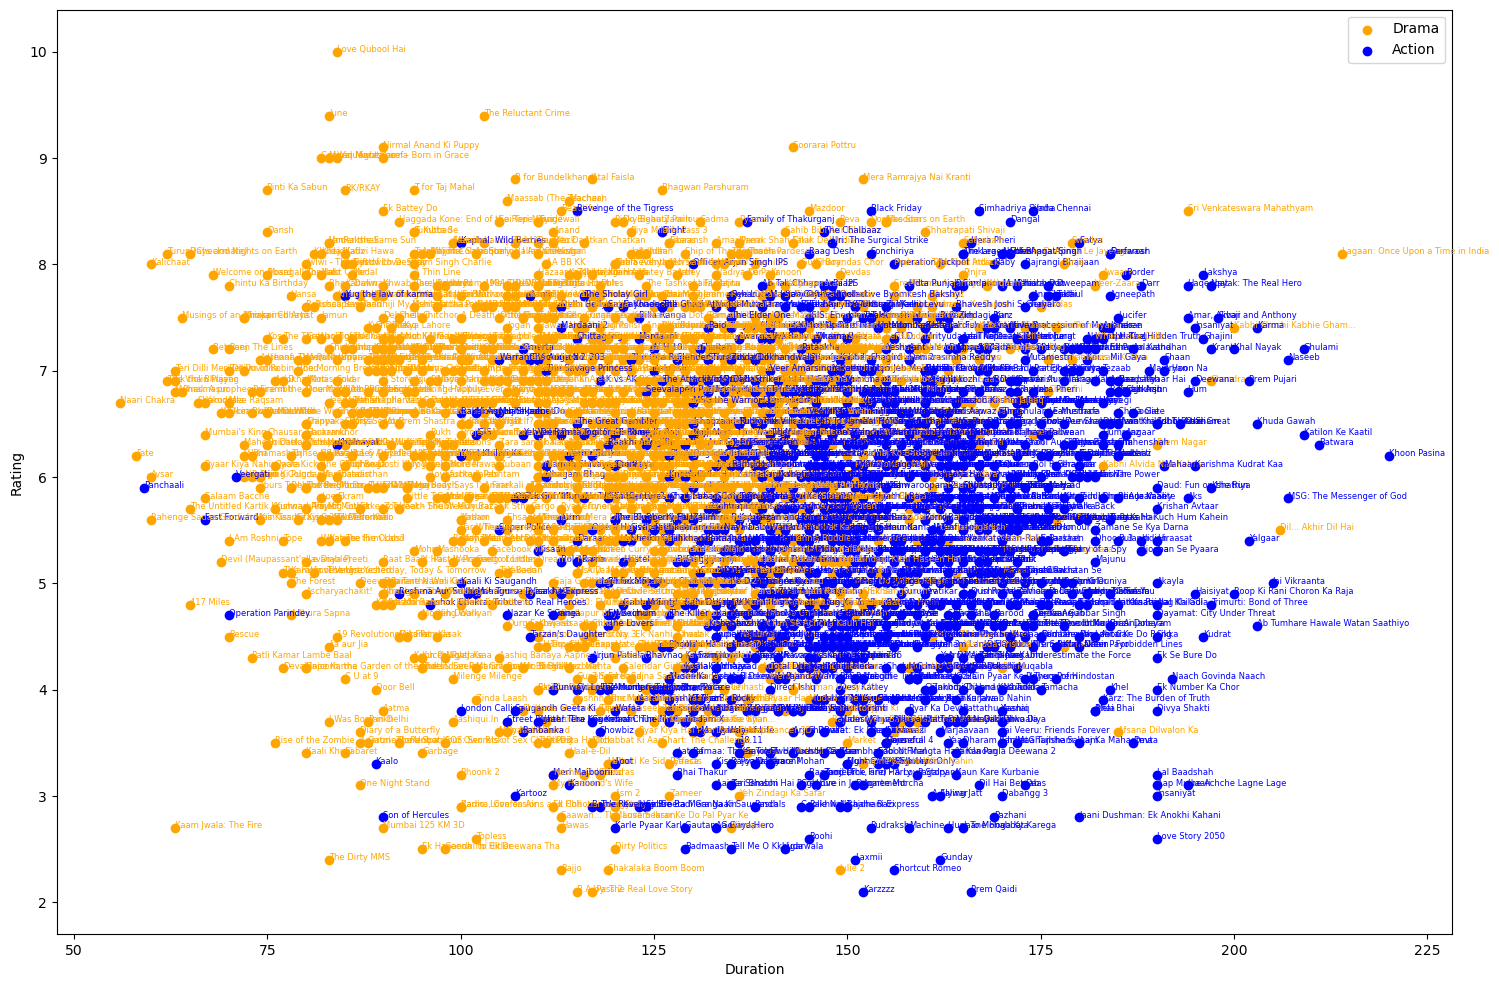

In [3]:
colors = np.where(df['Genre'] == "Drama", 'orange', 'blue')
fig = plt.figure(figsize=(18, 12))

drama = df[df['Genre'] == 'Drama']
action = df[df['Genre'] == 'Action']

plt.scatter(drama["Duration"], drama["Rating"], c='orange', label='Drama')
plt.scatter(action["Duration"], action["Rating"], c='blue', label='Action')

plt.xlabel("Duration")
plt.ylabel("Rating")
plt.legend()
for i in range(len(df)):
    plt.text(df["Duration"][i], df["Rating"][i], df["Name"][i], fontsize=6, color = colors[i])



    

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
neighbours = np.array(range(1,500,2))

In [5]:
from sklearn.model_selection import train_test_split

accuracy = []
#creating validate because we should not use test for choosing hyperparameters
train_df, validate_df = train_test_split(df, test_size=0.25)

print(f"Train size: {len(train_df)}, Validate size: {len(validate_df)}")

for idx, k in enumerate(neighbours):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_df[["Duration", "Rating"]], train_df["Genre"])
    y_pred = knn.predict(validate_df[["Duration", "Rating"]])
    cm = confusion_matrix(validate_df["Genre"], y_pred, labels=knn.classes_)
    tn, fp, fn, tp = cm.ravel()
    accuracy.append((tp + tn) / (tp + tn + fp + fn))

accuracy = np.array(accuracy)

Train size: 2097, Validate size: 700


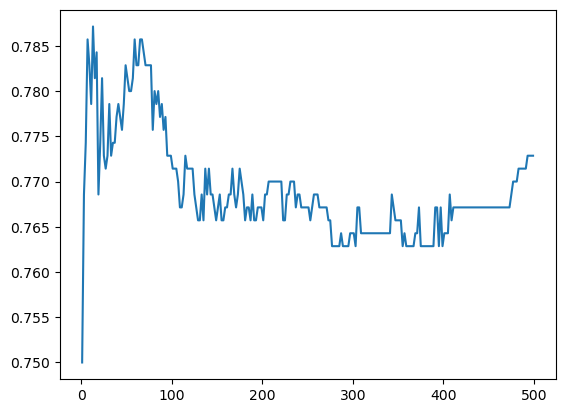

In [6]:
plt.plot(neighbours, accuracy)

In [7]:
k = accuracy.argmax()

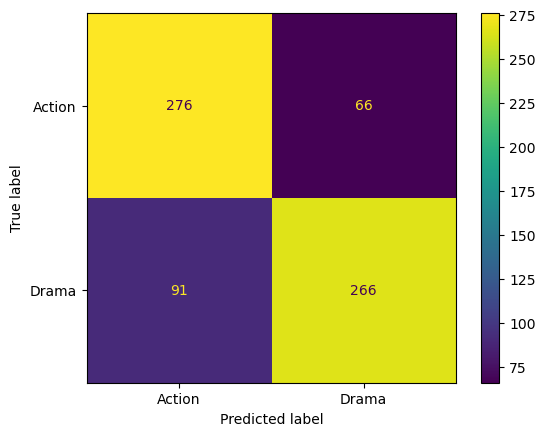

In [8]:
test_df = pd.read_csv('tblTest.csv')

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_df[["Duration", "Rating"]], train_df["Genre"])
y_pred = knn.predict(test_df[["Duration", "Rating"]])
cm = confusion_matrix(test_df["Genre"], y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot()
tn, fp, fn, tp = cm.ravel()

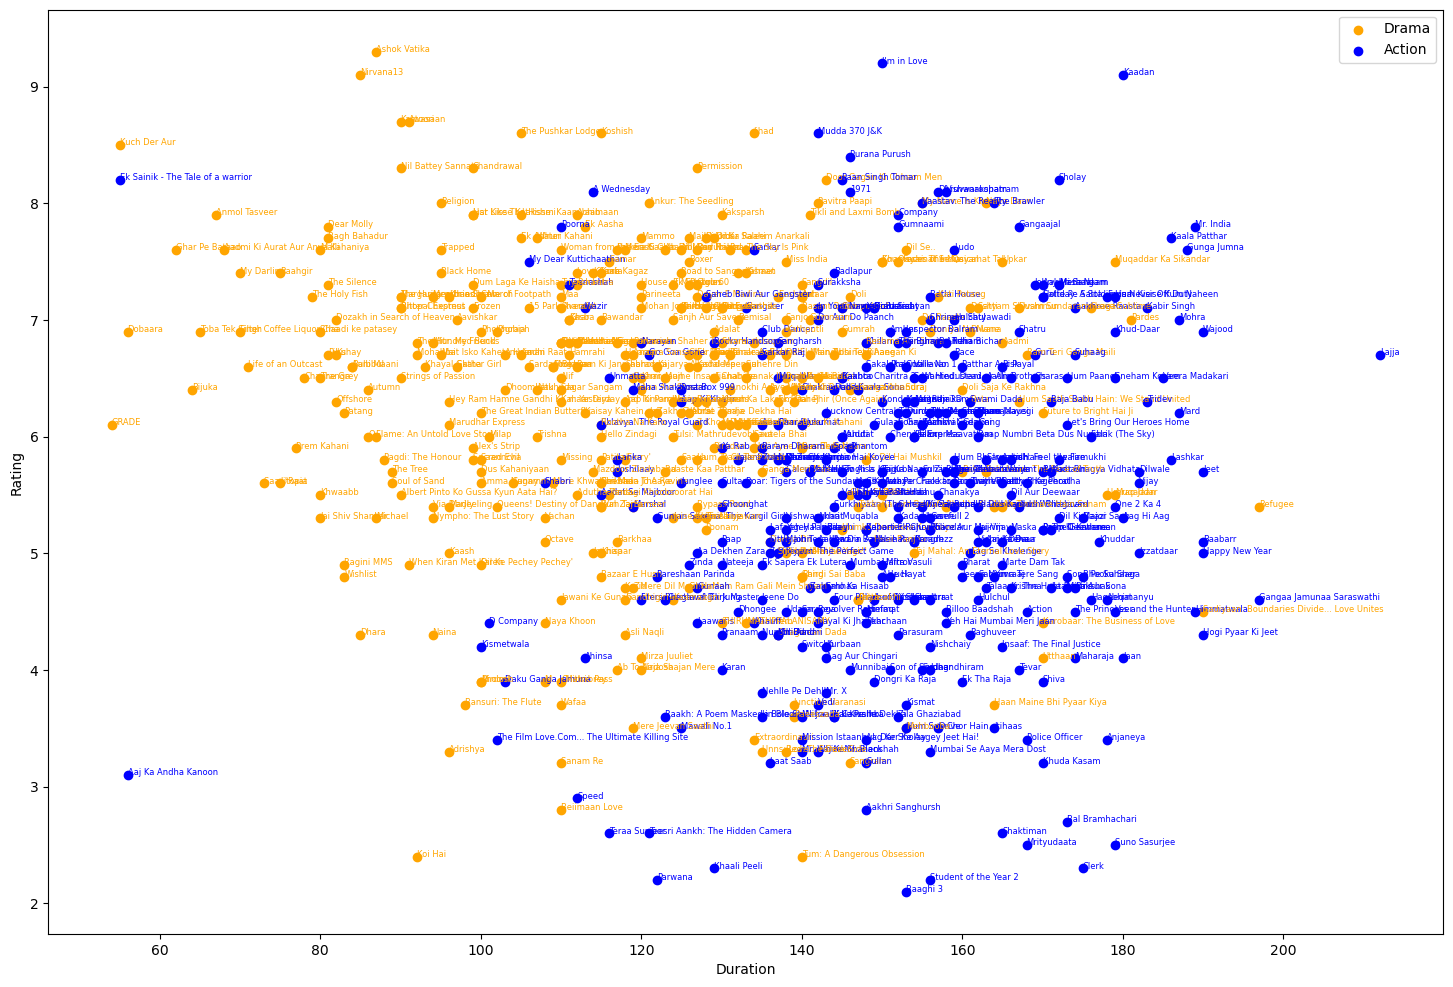

In [10]:

colors_test = np.where(test_df['Genre'] == "Drama", 'orange', 'blue')
fig = plt.figure(figsize=(18, 12))

drama_test = test_df[test_df['Genre'] == 'Drama']
action_test = test_df[test_df['Genre'] == 'Action']

plt.scatter(drama_test["Duration"], drama_test["Rating"], c='orange', label='Drama')
plt.scatter(action_test["Duration"], action_test["Rating"], c='blue', label='Action')

plt.xlabel("Duration")
plt.ylabel("Rating")
plt.legend()
test_df_reset = test_df.reset_index(drop=True)
for i in range(len(test_df_reset)):
    plt.text(test_df_reset["Duration"][i], test_df_reset["Rating"][i], test_df_reset["Name"][i], fontsize=6, color=colors_test[i])

In [9]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)
F_score = 2 * (precision * recall) / (precision + recall)
print(f"Precision: {precision}, Recall: {recall}, F-score: {F_score}")

Precision: 0.8012048192771084, Recall: 0.7450980392156863, F-score: 0.7721335268505081


**1. What does the 'k' value in KNN determine?**

The 'k' value determines the number of nearest neighbors that are used to classify.

**2. How is the optimal 'k' value in KNN typically chosen?**

The optimal 'k' is typically chosen through cross-validation or by using a validation set.

**3. How does the value of 'k' affect variance and bias in KNN?**

- Low k: High variance, low bias. The model is sensitive to noise and outliers, causes overfitting.
- High k: Low variance, high bias. The model is smooth and may underfit

**4. Is KNN sensitive to outliers, and why?**

Yes, KNN is sensitive to outliers, especially at small k values. An outlier among the k nearest neighbors can significantly change the classification.

**5. How does the scale of features affect the performance of KNN?**

The scale features affects the performance as the larger distances can dominate the distance, making other features less imapctful.